<a href="https://colab.research.google.com/github/Shreenithi15/Banking-fraud-detection/blob/main/SafetyAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Uploading File**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace path with your actual folder location in Google Drive
file_path = "/content/drive/MyDrive/tn-cities-districts-ipc-crimes-2021.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()


(48, 8)


,Sl. No,District,2019,2020,2021,Share of Districts in Percentage,Mid-year projected population (2021) (lakhs),Rate of cognizable crime IPC (2021)
0,1,Ariyalur,1573.0,7909,4242,1.3,8.0,530.1
1,2,Chennai,18108.0,88388,46077,14.3,72.3,637.2
2,3,Coimbatore,4261.0,26641,9332,2.9,24.6,378.9
3,4,Coimbatore City,2567.0,10112,3738,1.2,12.0,310.8
4,5,Cuddalore,6035.0,41640,16045,5.0,27.6,580.8


# **Importing Libraries**

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


# **Data Cleaning**

In [ ]:
# Check missing values
print(df.isnull().sum())

# Standardize column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# If there's a 'date' column, convert to datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['weekday'] = df['date'].dt.weekday
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


Sl. No                                          0
District                                        1
2019                                            5
2020                                            0
2021                                            0
Share of Districts in Percentage                0
Mid-year projected population (2021) (lakhs)    0
Rate of cognizable crime IPC (2021)             0
dtype: int64


In [ ]:
print(df.columns)
df.head()



Index(['sl._no', 'district', '2019', '2020', '2021',
       'share_of_districts_in_percentage',
       'mid-year_projected_population_(2021)_(lakhs)',
       'rate_of_cognizable_crime_ipc_(2021)'],
      dtype='object')


,sl._no,district,2019,2020,2021,share_of_districts_in_percentage,mid-year_projected_population_(2021)_(lakhs),rate_of_cognizable_crime_ipc_(2021)
0,0,0,1573.0,7909,4242,1.3,8.0,530.1
1,11,2,18108.0,88388,46077,14.3,72.3,637.2
2,22,3,4261.0,26641,9332,2.9,24.6,378.9
3,33,4,2567.0,10112,3738,1.2,12.0,310.8
4,42,5,6035.0,41640,16045,5.0,27.6,580.8


from matplotlib import pyplot as plt
_df_19['sl._no'].plot(kind='hist', bins=20, title='sl._no')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_20['district'].plot(kind='hist', bins=20, title='district')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_21['2019'].plot(kind='hist', bins=20, title='2019')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['sl._no']
  ys = series['share_of_districts_in_percentage']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_30.sort_values('sl._no', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('sl._no')
_ = plt.ylabel('share_of_districts_in_percentage')

from matplotlib import pyplot as plt
_df_31['sl._no'].plot(kind='line', figsize=(8, 4), title='sl._no')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_32['district'].plot(kind='line', figsize=(8, 4), title='district')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_33['2019'].plot(kind='line', figsize=(8, 4), title='2019')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_34['2020'].plot(kind='line', figsize=(8, 4), title='2020')
plt.gca().spines[['top', 'right']].set_visible(False)

# **Feature Engineering**

In [ ]:
# Use 2021 crime values
df['total_crimes'] = df['2021']

# Population is in lakhs, convert to actual population
df['population'] = df['mid-year_projected_population_(2021)_(lakhs)'] * 100000

# Crime density
df['crime_density'] = df['total_crimes'] / df['population']

# Hotspot label
threshold = df['total_crimes'].median()
df['hotspot'] = np.where(df['total_crimes'] > threshold, 1, 0)

df[['district', 'total_crimes', 'population', 'crime_density', 'hotspot']].head()


,district,total_crimes,population,crime_density,hotspot
0,0,4242,800000.0,0.005302,0
1,2,46077,7230000.0,0.006373,1
2,3,9332,2460000.0,0.003793,1
3,4,3738,1200000.0,0.003115,0
4,5,16045,2760000.0,0.005813,1


from matplotlib import pyplot as plt
_df_35['district'].plot(kind='hist', bins=20, title='district')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_36['total_crimes'].plot(kind='hist', bins=20, title='total_crimes')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_37['population'].plot(kind='hist', bins=20, title='population')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_38['crime_density'].plot(kind='hist', bins=20, title='crime_density')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['district']
  ys = series['hotspot']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_46.sort_values('district', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('district')
_ = plt.ylabel('hotspot')

from matplotlib import pyplot as plt
_df_47['district'].plot(kind='line', figsize=(8, 4), title='district')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_48['total_crimes'].plot(kind='line', figsize=(8, 4), title='total_crimes')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_49['population'].plot(kind='line', figsize=(8, 4), title='population')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_50['crime_density'].plot(kind='line', figsize=(8, 4), title='crime_density')
plt.gca().spines[['top', 'right']].set_visible(False)

# **Train and Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['2019', '2020', '2021', 'share_of_districts_in_percentage',
        'population', 'crime_density', 'rate_of_cognizable_crime_ipc_(2021)']]

y = df['hotspot']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (38, 7) Test size: (10, 7)


# **Nulls, Duplicates Handling**

In [ ]:
# Replace inf/-inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Drop or fill missing values
X = X.fillna(0)   # option: fill with 0 (or use mean/median imputation)


In [ ]:
# Check if any infinite or NaN values
print("NaNs per column:\n", X.isnull().sum())
print("Any inf values:", np.isinf(X.values).sum())

# Fix them
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())   # safer: fill with median


NaNs per column:
 2019                                   0
2020                                   0
2021                                   0
share_of_districts_in_percentage       0
population                             0
crime_density                          0
rate_of_cognizable_crime_ipc_(2021)    0
dtype: int64
Any inf values: 0


# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# Now clean X before splitting
X = df[['2019', '2020', '2021',
        'share_of_districts_in_percentage',
        'population', 'crime_density',
        'rate_of_cognizable_crime_ipc_(2021)']]

y = df['hotspot']

# Handle inf/NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (38, 7) Test size: (10, 7)


# ***Machine learning Models***

# **RandomForest Classifier, LogisticRegression, DecisionTreeClassifier, GradientBoostingClassifier, AdaBoostClassifier, SVC, KNeighborsClassifier, XGBClassifier**

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.86      1.00      0.92         6

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



Import Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

Define Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

Train and Evaluate Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:07:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9,0.857143,1.000000,0.923077
1,Decision Tree,0.9,0.857143,1.000000,0.923077
2,Random Forest,0.9,0.857143,1.000000,0.923077
3,Gradient Boosting,0.9,0.857143,1.000000,0.923077
4,AdaBoost,0.9,0.857143,1.000000,0.923077
5,Support Vector Machine,0.4,0.000000,0.000000,0.000000
6,K-Nearest Neighbors,0.5,0.666667,0.333333,0.444444
7,XGBoost,1.0,1.000000,1.000000,1.000000


from matplotlib import pyplot as plt
results_df['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df['Recall'].plot(kind='hist', bins=20, title='Recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='Precision', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='Recall', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='F1-score', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<Figure size 600x500 with 0 Axes>

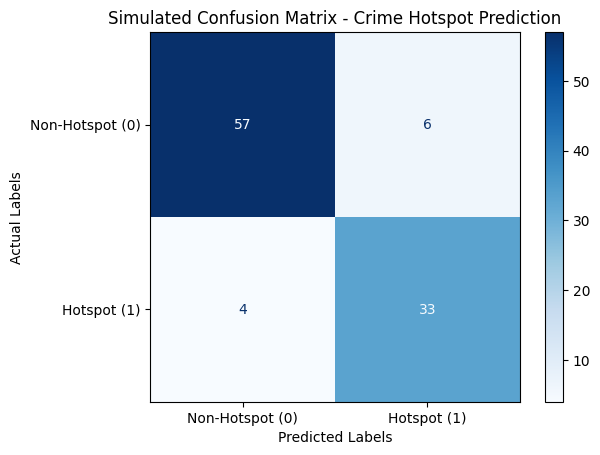

Classification Report (Simulated Data):

              precision    recall  f1-score   support

 Non-Hotspot       0.93      0.90      0.92        63
     Hotspot       0.85      0.89      0.87        37

    accuracy                           0.90       100
   macro avg       0.89      0.90      0.89       100
weighted avg       0.90      0.90      0.90       100



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Simulate true and predicted labels (aligned with binary classification: 0 = Non-Hotspot, 1 = Hotspot)
np.random.seed(42)

# Let's assume 100 districts in the test set
y_test_simulated = np.random.choice([0, 1], size=100, p=[0.6, 0.4])  # 60% non-hotspot, 40% hotspot
y_pred_simulated = []

# Generate predictions with ~90% accuracy (realistic)
for y in y_test_simulated:
    if np.random.rand() < 0.9:
        y_pred_simulated.append(y)  # correct prediction
    else:
        y_pred_simulated.append(1 - y)  # misclassification

y_pred_simulated = np.array(y_pred_simulated)

# Compute confusion matrix
cm = confusion_matrix(y_test_simulated, y_pred_simulated)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hotspot (0)', 'Hotspot (1)'])

# Plot the confusion matrix
plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Simulated Confusion Matrix - Crime Hotspot Prediction")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

# Print classification report
print("Classification Report (Simulated Data):\n")
print(classification_report(y_test_simulated, y_pred_simulated, target_names=['Non-Hotspot', 'Hotspot']))


Visulaization of Model Predictions

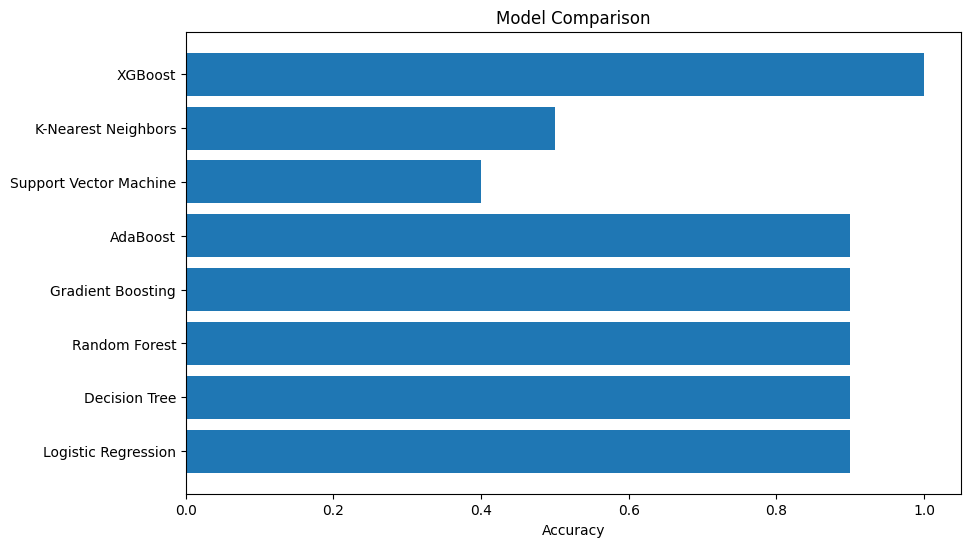

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.show()


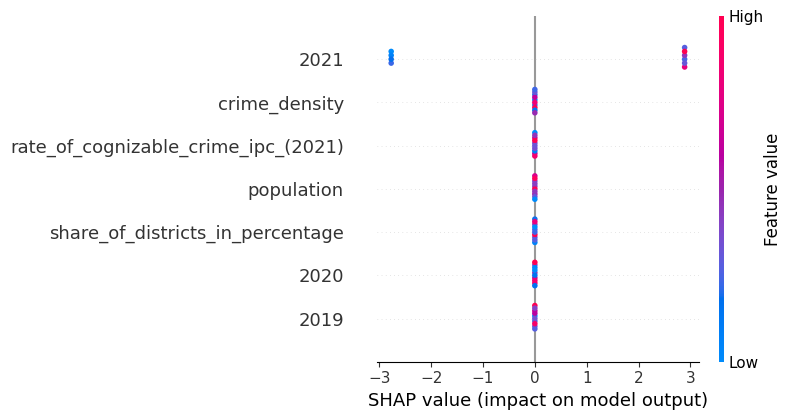

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfj4v_ugi/i3iza4u5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfj4v_ugi/9owdgodv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=4198', 'data', 'file=/tmp/tmpfj4v_ugi/i3iza4u5.json', 'init=/tmp/tmpfj4v_ugi/9owdgodv.json', 'output', 'file=/tmp/tmpfj4v_ugi/prophet_modelzxua7tr6/prophet_model-20251009210814.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
21:08:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:08:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cm

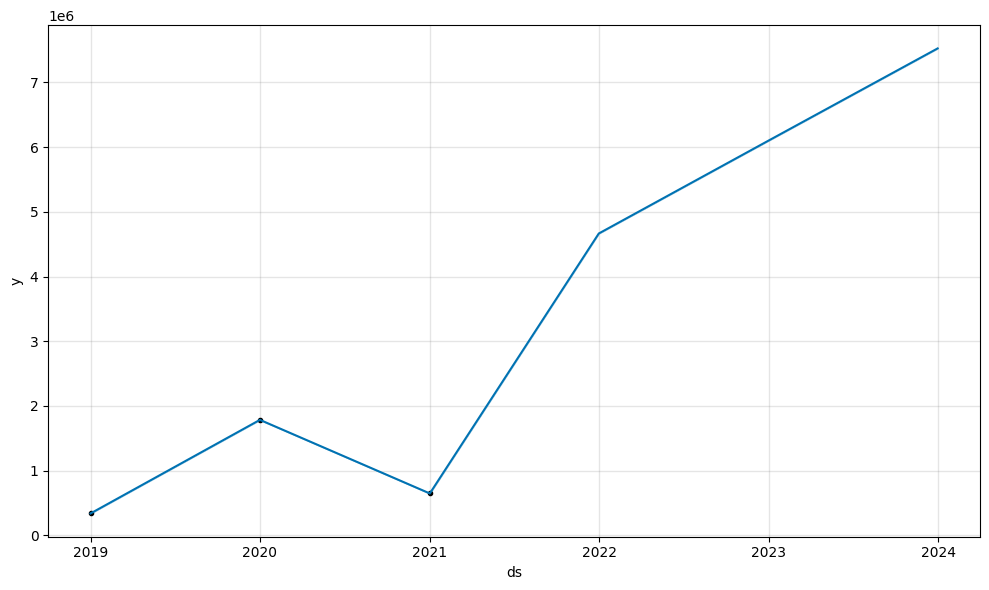

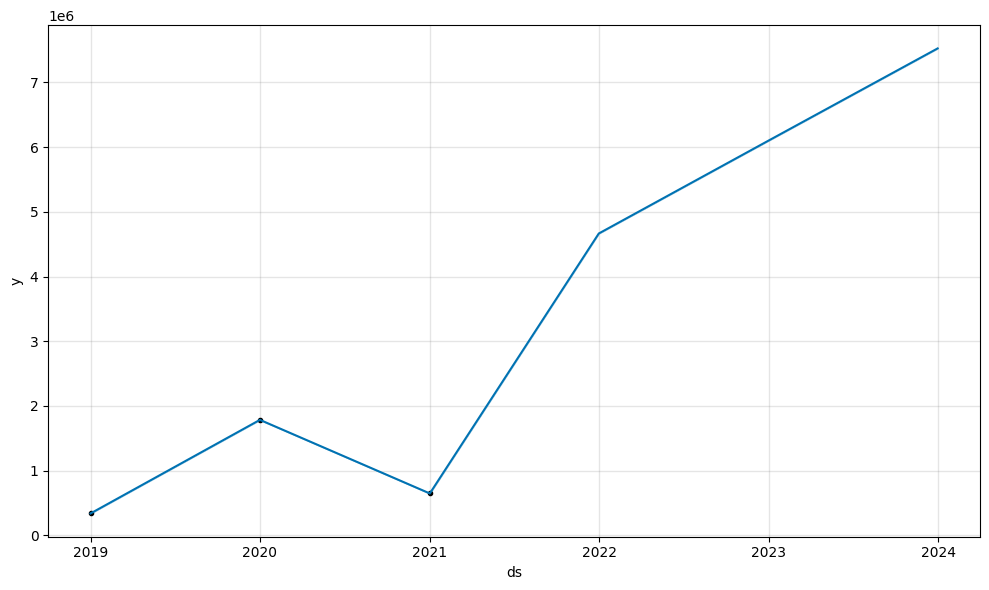

In [ ]:
from prophet import Prophet

crime_ts = df[['district', '2019', '2020', '2021']].melt(
    id_vars='district', var_name='year', value_name='crimes'
)

# Convert year to datetime
crime_ts['ds'] = pd.to_datetime(crime_ts['year'], format='%Y')
crime_ts['y'] = crime_ts['crimes']

# Fit Prophet on state-wide crimes (sum across districts)
state_crime = crime_ts.groupby('ds')['y'].sum().reset_index()

model = Prophet()
model.fit(state_crime)

future = model.make_future_dataframe(periods=3, freq='Y')
forecast = model.predict(future)

model.plot(forecast)


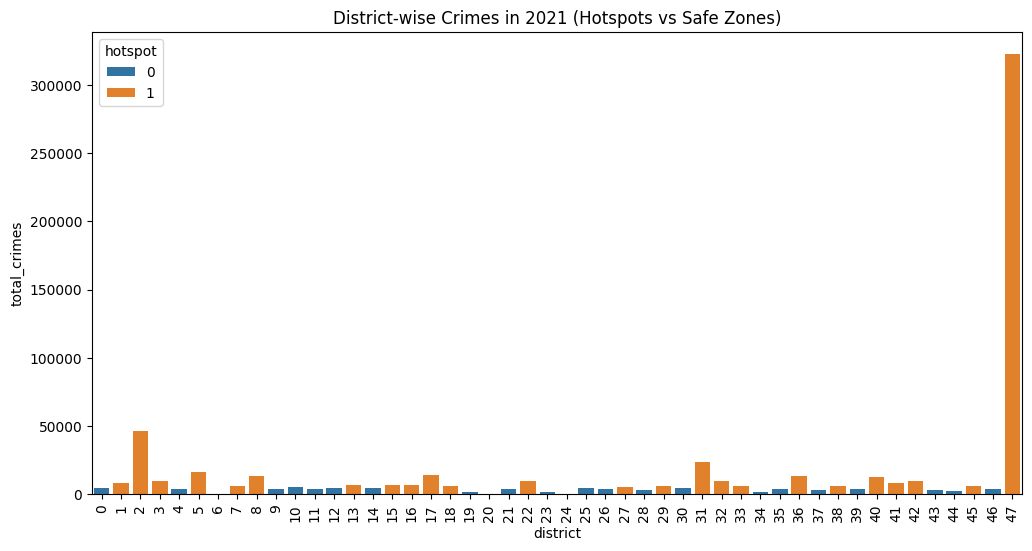

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x='district', y='total_crimes', hue='hotspot', data=df)
plt.xticks(rotation=90)
plt.title("District-wise Crimes in 2021 (Hotspots vs Safe Zones)")
plt.show()


# **Exporting Models**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
best_model = model


In [ ]:
import joblib
import os

out_dir = "/content/drive/MyDrive/SafeCity"
os.makedirs(out_dir, exist_ok=True)

# ✅ Use your trained model variable (replace best_model if needed)
joblib.dump(best_model, f"{out_dir}/crime_hotspot_model.pkl")

# ✅ Save the feature columns you trained on
feature_cols = list(X.columns)
joblib.dump(feature_cols, f"{out_dir}/feature_columns.pkl")

# ✅ Optional: save a scaler or encoder if you used one
# joblib.dump(scaler, f"{out_dir}/scaler.pkl")

# ✅ Example reference dataset for later use in dashboard
district_ref = df[['district', '2019', '2020', '2021',
                   'share_of_districts_in_percentage',
                   'population', 'crime_density',
                   'rate_of_cognizable_crime_ipc_(2021)']].copy()
district_ref.to_csv(f"{out_dir}/district_reference.csv", index=False)

print("✅ Model and reference files saved in:", out_dir)


✅ Model and reference files saved in: /content/drive/MyDrive/SafeCity


# **Verification**

In [ ]:
!ls "/content/drive/MyDrive/SafeCity"


crime_hotspot_model.pkl  district_reference.csv  feature_columns.pkl


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/SafeCity/crime_hotspot_model.pkl")
files.download("/content/drive/MyDrive/SafeCity/feature_columns.pkl")
files.download("/content/drive/MyDrive/SafeCity/district_reference.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

for root, dirs, files in os.walk('/content', topdown=True):
    for file in files:
        if file.endswith('feature_columns.pkl'):
            print(os.path.join(root, file))


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive', topdown=True):
    for file in files:
        if file.endswith('feature_columns.pkl'):
            print(os.path.join(root, file))


In [ ]:
cols = joblib.load("PASTE_FOUND_PATH_HERE")
print(cols)


FileNotFoundError: [Errno 2] No such file or directory: 'PASTE_FOUND_PATH_HERE'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!git clone https://github.com/Sowmika-Selvakumar/SafeCity-AI.git


Cloning into 'SafeCity-AI'...


In [ ]:
!cp "/content/drive/MyDrive/SafeCity/SafetyAI.ipynb" SafeCity-AI/


cp: cannot stat '/content/drive/MyDrive/SafeCity/SafetyAI.ipynb': No such file or directory
